# 08 — ESP32-S3 hardware analysis
Đọc `results/hardware/hardware_benchmark.csv` và `hardware_predictions.csv` do `src/esp32_gateway.py` tạo khi chạy với board thật.

**Training platform:** CPU (PC) — **Deployment platform:** ESP32-S3 (encoder + INT8 + packet; decoder + classifier ở gateway PC).
Chỉ kết luận về khả năng chạy, latency, bộ nhớ và payload — **không** kết luận về năng lượng/pin (chưa đo dòng điện).

`TAG = ''` → dữ liệu board thật. `TAG = 'qemu'` → chỉ để kiểm thử notebook bằng log giả lập QEMU (latency QEMU **không** phải số đo phần cứng).

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plotstyle; plotstyle.apply()
from plotstyle import SERIES, TEXT2, METHOD_COLORS
HW = ROOT / 'results' / 'hardware'; FIG = ROOT / 'results' / 'figures'; SUM = ROOT / 'results' / 'summary'
TAG = ''
sfx = f'_{TAG}' if TAG else ''
bench = pd.read_csv(HW / f'hardware_benchmark{sfx}.csv')
preds = pd.read_csv(HW / f'hardware_predictions{sfx}.csv')
print(bench.groupby('d').run_id.unique())

d
64      [d64_20261005_201429]
128    [d128_20261005_193250]
256    [d256_20261005_195354]
Name: run_id, dtype: object


## Latency statistics (≥ 50 warm-up, ≥ 1000 measured runs, batch = 1)

In [2]:
def stats(s):
    return pd.Series({'mean': s.mean(), 'median': s.median(), 'std': s.std(), 'min': s.min(), 'max': s.max(),
                      'p95': s.quantile(0.95), 'n': len(s)})
metrics = ['preprocess_ms', 'encoder_ms', 'quantization_ms', 'packetization_ms', 'total_node_ms', 'end_to_end_node_ms']
lat = pd.concat({m: bench.groupby('d')[m].apply(stats).unstack() for m in metrics}, names=['metric'])
lat.to_csv(HW / f'hardware_latency_stats{sfx}.csv'); lat

mean   median           std      min      max  \
metric             d                                                          
preprocess_ms      64    95.392069   95.392  3.638288e-04   95.392   95.394   
                   128   95.652000   95.652  2.843593e-14   95.652   95.652   
                   256   95.754026   95.754  1.592148e-04   95.754   95.755   
encoder_ms         64   489.020706  489.020  9.739161e-04  489.020  489.025   
                   128  490.751338  490.751  4.816513e-04  490.751  490.754   
                   256  494.682676  494.682  9.715801e-04  494.682  494.690   
quantization_ms    64     0.029634    0.029  9.575808e-04    0.028    0.031   
                   128    0.056668    0.056  9.437514e-04    0.056    0.058   
                   256    0.109667    0.109  9.428680e-04    0.109    0.111   
packetization_ms   64     0.001034    0.001  1.813198e-04    0.001    0.002   
                   128    0.001001    0.001  3.162278e-05    0.001    0.002   
                   256    0.002000    0.002  8.677957e-19    0.002    0.002   
total_node_ms      64   489.051374  489.050  1.906242e-03  489.050  489.057   
                   128  490.809007  490.808  1.423017e-03  490.808  490.814   
                   256  494.794343  494.793  1.900780e-03  494.793  494.802   
end_to_end_node_ms 64   584.443443  584.442  1.987134e-03  584.442  584.451   
                   128  586.461007  586.460  1.423017e-03  586.460  586.466   
                   256  590.548369  590.547  1.905904e-03  590.547  590.556   

                            p95       n  
metric             d                     
preprocess_ms      64    95.392  1000.0  
                   128   95.652  1000.0  
                   256   95.754  1000.0  
encoder_ms         64   489.022  1000.0  
                   128  490.752  1000.0  
                   256  494.684  1000.0  
quantization_ms    64     0.031  1000.0  
                   128    0.058  1000.0  
                   256    0.111  1000.0  
packetization_ms   64     0.001  1000.0  
                   128    0.001  1000.0  
                   256    0.002  1000.0  
total_node_ms      64   489.054  1000.0  
                   128  490.811  1000.0  
                   256  494.797  1000.0  
end_to_end_node_ms 64   584.446  1000.0  
                   128  586.463  1000.0  
                   256  590.551  1000.0

## Memory / Flash

In [3]:
mem = bench.groupby('d')[['free_heap_bytes', 'min_free_heap_bytes', 'psram_free_bytes', 'activation_buffers_bytes',
                           'model_size_bytes', 'firmware_size_bytes', 'payload_bytes', 'packet_bytes']].first()
(mem / 1000).round(1).add_suffix(' (kB)')

,free_heap_bytes (kB),min_free_heap_bytes (kB),psram_free_bytes (kB),activation_buffers_bytes (kB),model_size_bytes (kB),firmware_size_bytes (kB),payload_bytes (kB),packet_bytes (kB)
d,,,,,,,,
64,8570.1,8538.1,8353.4,141.1,371.7,1009.8,0.1,0.1
128,8570.1,8538.1,8353.4,141.1,372.8,1010.8,0.1,0.1
256,8570.1,8538.1,8353.4,141.1,374.8,1012.9,0.3,0.3


## Figure H1 — Encoder latency vs d

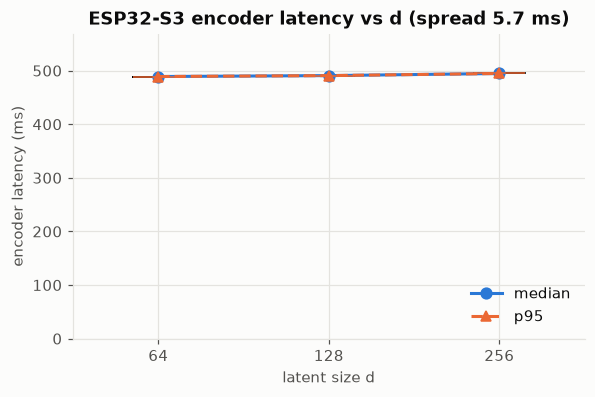

In [4]:
g = bench.groupby('d').encoder_ms
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.boxplot([bench[bench.d == d].encoder_ms for d in sorted(bench.d.unique())], tick_labels=sorted(bench.d.unique()),
           showfliers=False)
ax.plot(range(1, len(g.median()) + 1), g.median().values, marker='o', color=SERIES[0], label='median')
ax.plot(range(1, len(g.median()) + 1), g.quantile(.95).values, marker='^', ls='--', color=SERIES[1], label='p95')
ax.set(xlabel='latent size d', ylabel='encoder latency (ms)', ylim=(0, g.quantile(.95).max() * 1.15), title=f'ESP32-S3 encoder latency vs d (spread {g.median().max() - g.median().min():.1f} ms)'); ax.legend(loc='lower right')
fig.savefig(FIG / f'hw_encoder_latency_vs_d{sfx}.png'); plt.show()

## Figure H2 — RAM usage vs d

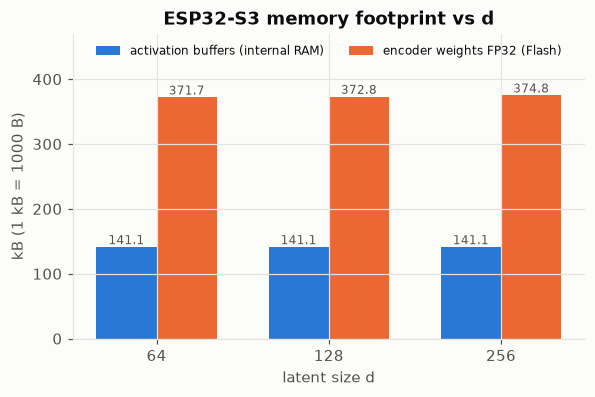

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.6)); ds = sorted(bench.d.unique()); w = 0.35
b1 = ax.bar(np.arange(len(ds)) - w/2, mem.loc[ds, 'activation_buffers_bytes'] / 1000, w, color=SERIES[0], label='activation buffers (internal RAM)')
b2 = ax.bar(np.arange(len(ds)) + w/2, mem.loc[ds, 'model_size_bytes'] / 1000, w, color=SERIES[1], label='encoder weights FP32 (Flash)')
ax.bar_label(b1, fmt='%.1f', fontsize=8, color=TEXT2); ax.bar_label(b2, fmt='%.1f', fontsize=8, color=TEXT2)
ax.set_xticks(range(len(ds)), ds); ax.set(xlabel='latent size d', ylabel='kB (1 kB = 1000 B)', ylim=(0, 470), title='ESP32-S3 memory footprint vs d')
ax.legend(loc='upper center', ncol=2, fontsize=8)
fig.savefig(FIG / f'hw_memory_vs_d{sfx}.png'); plt.show()

## Figure H3 — Packet bytes vs accuracy
Phần mềm: Task-AE trung bình 6 fold (seed 0). Phần cứng: accuracy tính từ packet thật do ESP32-S3 tạo (fold xuất model).

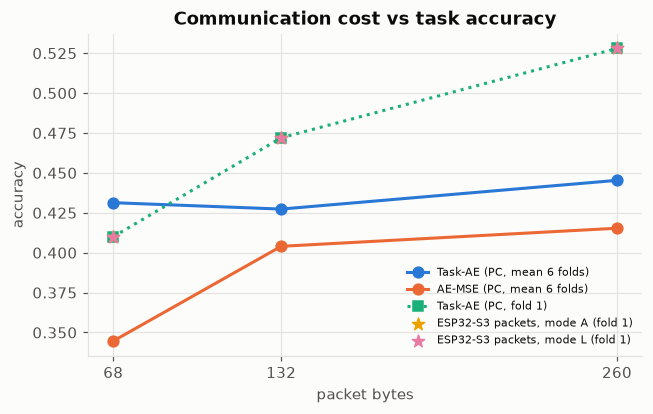

In [6]:
s = pd.read_csv(SUM / 'results_summary.csv'); s0 = s[s.seed == 0]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for m in ['Task-AE', 'AE-MSE']:
    g = s0[s0.method == m].groupby('bytes').Accuracy.mean()
    ax.plot(g.index, g.values, marker='o', color=METHOD_COLORS[m], label=f'{m} (PC, mean 6 folds)')
fold = int(preds.fold.iloc[0])
sw = s0[(s0.method == 'Task-AE') & (s0.fold == fold)].set_index('bytes').Accuracy
ax.plot(sw.index, sw.values, marker='s', ls=':', color=SERIES[2], label=f'Task-AE (PC, fold {fold})')
hw = preds.groupby(['packet_bytes', 'mode']).apply(lambda g: (g.label == g.prediction_esp32_packet).mean(), include_groups=False).unstack()
for i, mode in enumerate(hw.columns):
    ax.scatter(hw.index, hw[mode], s=70, marker='*', color=SERIES[3 + i], zorder=3, label=f'ESP32-S3 packets, mode {mode} (fold {fold})')
ax.set_xticks([68, 132, 260]); ax.set(xlabel='packet bytes', ylabel='accuracy', title='Communication cost vs task accuracy')
ax.legend(fontsize=7); fig.savefig(FIG / f'hw_packet_bytes_vs_accuracy{sfx}.png'); plt.show()

## Figure H4 — Compression ratio vs ESP32 latency

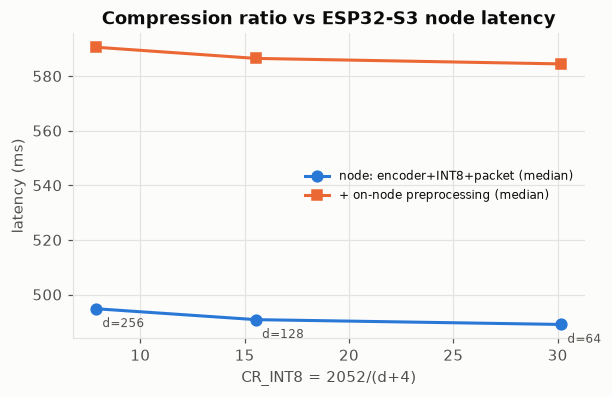

In [7]:
g = bench.groupby('d')[['total_node_ms', 'end_to_end_node_ms']].median(); cr = 2052 / (g.index + 4)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(cr, g.total_node_ms, marker='o', color=SERIES[0], label='node: encoder+INT8+packet (median)')
ax.plot(cr, g.end_to_end_node_ms, marker='s', color=SERIES[1], label='+ on-node preprocessing (median)')
for c, d in zip(cr, g.index): ax.annotate(f'd={d}', (c, g.loc[d, 'total_node_ms']), xytext=(4, -12), textcoords='offset points', fontsize=8, color=TEXT2)
ax.set(xlabel='CR_INT8 = 2052/(d+4)', ylabel='latency (ms)', title='Compression ratio vs ESP32-S3 node latency'); ax.legend(fontsize=8)
fig.savefig(FIG / f'hw_cr_vs_latency{sfx}.png'); plt.show()

## Hardware consistency (Python INT8 vs ESP32 INT8, prediction agreement)

In [8]:
cons = preds.groupby(['d', 'mode']).agg(n=('match', 'size'), prediction_agreement=('match', 'mean'),
    latent_exact_ratio=('latent_exact_ratio', 'mean'), max_abs_q_diff=('latent_max_abs_diff', 'max'),
    acc_python=('prediction_python', lambda p: np.nan), packet_bytes=('packet_bytes', 'first'))
cons['acc_python'] = preds.groupby(['d', 'mode']).apply(lambda g: (g.label == g.prediction_python).mean(), include_groups=False)
cons['acc_esp32'] = preds.groupby(['d', 'mode']).apply(lambda g: (g.label == g.prediction_esp32_packet).mean(), include_groups=False)
cons.to_csv(HW / f'hardware_consistency{sfx}.csv'); cons

n  prediction_agreement  latent_exact_ratio  max_abs_q_diff  \
d   mode                                                                  
64  A     500                   1.0            0.999906               1   
    L     500                   1.0            1.000000               0   
128 A     500                   1.0            0.999969               1   
    L     500                   1.0            0.999984               1   
256 A     500                   1.0            0.999977               1   
    L     500                   1.0            1.000000               0   

          acc_python  packet_bytes  acc_esp32  
d   mode                                       
64  A          0.410            68      0.410  
    L          0.410            68      0.410  
128 A          0.472           132      0.472  
    L          0.472           132      0.472  
256 A          0.528           260      0.528  
    L          0.528           260      0.528